In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load dataset

In [2]:
df = pd.read_csv("../data/raw/silver_prices_historical.csv")

check first 5 data using head

In [3]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,MA_50,MA_200,Daily_Return,Year,Month,Volatility_30d
0,2016-01-04,13.817,13.817,14.100,13.817,14.100,27,NaN,NaN,NaN,2016,1,NaN
1,2016-01-05,13.949,13.949,13.949,13.949,13.949,4,NaN,NaN,0.955345,2016,1,NaN
2,2016-01-06,13.957,13.957,14.065,13.957,14.000,105,NaN,NaN,0.057348,2016,1,NaN
3,2016-01-07,14.335,14.335,14.340,14.330,14.335,286,NaN,NaN,2.708320,2016,1,NaN
4,2016-01-08,13.908,13.908,14.060,13.908,14.060,6,NaN,NaN,-2.978724,2016,1,NaN


check the no. of rows and columns

In [4]:
df.shape

(2524, 13)

check all column names

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2524 entries, 0 to 2523
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2524 non-null   object 
 1   Adj Close       2524 non-null   float64
 2   Close           2524 non-null   float64
 3   High            2524 non-null   float64
 4   Low             2524 non-null   float64
 5   Open            2524 non-null   float64
 6   Volume          2524 non-null   int64  
 7   MA_50           2475 non-null   float64
 8   MA_200          2325 non-null   float64
 9   Daily_Return    2523 non-null   float64
 10  Year            2524 non-null   int64  
 11  Month           2524 non-null   int64  
 12  Volatility_30d  2494 non-null   float64
dtypes: float64(9), int64(3), object(1)
memory usage: 256.5+ KB


Statistical summary

In [6]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume,MA_50,MA_200,Daily_Return,Year,Month,Volatility_30d
count,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2475.000000,2325.000000,2523.000000,2524.00000,2524.000000,2494.000000
mean,22.801023,22.801023,22.971160,22.636807,22.804289,1770.335578,22.409436,21.845891,0.091614,2020.52813,6.518225,27.462133
std,8.940979,8.940979,9.098045,8.760359,8.917146,10119.546151,7.378619,5.786369,1.903569,2.88785,3.437348,11.148306
min,11.735000,11.735000,12.205000,11.735000,12.070000,0.000000,14.370120,14.849745,-11.649142,2016.00000,1.000000,11.163540
25%,16.802750,16.802750,16.874000,16.740000,16.829250,10.000000,16.750800,16.930470,-0.819752,2018.00000,4.000000,19.621703
50%,21.267000,21.267000,21.552501,20.982500,21.172500,49.000000,21.684600,21.435020,0.092938,2021.00000,7.000000,25.003781
75%,25.481750,25.481750,25.711249,25.266250,25.503750,176.250000,25.108920,24.831510,0.954361,2023.00000,10.000000,31.705555
max,91.875999,91.875999,93.000000,88.705002,90.824997,131415.000000,63.662880,44.859390,10.762136,2026.00000,12.000000,77.140974


check null value and how many null values

In [7]:
df.isnull().sum()

Date                0
Adj Close           0
Close               0
High                0
Low                 0
Open                0
Volume              0
MA_50              49
MA_200            199
Daily_Return        1
Year                0
Month               0
Volatility_30d     30
dtype: int64

convert date column

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df = df.sort_values('Date')

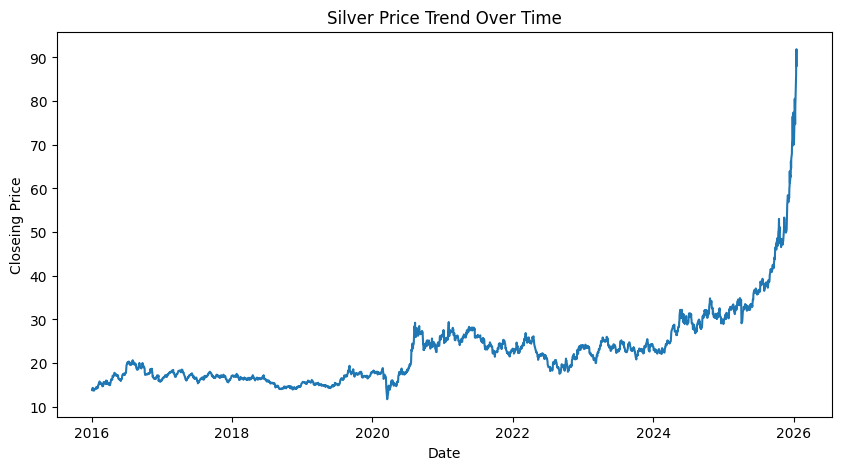

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.title("Silver Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closeing Price")
plt.show()


In [11]:
df.to_csv("../data/processed/cleaned_silver_prices.csv", index=False)

In [12]:
df.isnull().sum()

Date                0
Adj Close           0
Close               0
High                0
Low                 0
Open                0
Volume              0
MA_50              49
MA_200            199
Daily_Return        1
Year                0
Month               0
Volatility_30d     30
dtype: int64

to handle missing values

In [13]:
df = df.fillna(method = 'bfill')

C:\Users\vatss\AppData\Local\Temp\ipykernel_14932\2090509475.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method = 'bfill')


drop duplicate rows

In [14]:
df = df.drop_duplicates()

confirm data types

In [15]:
df.dtypes

Date              datetime64[ns]
Adj Close                float64
Close                    float64
High                     float64
Low                      float64
Open                     float64
Volume                     int64
MA_50                    float64
MA_200                   float64
Daily_Return             float64
Year                       int64
Month                      int64
Volatility_30d           float64
dtype: object

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2524 entries, 0 to 2523
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2524 non-null   datetime64[ns]
 1   Adj Close       2524 non-null   float64       
 2   Close           2524 non-null   float64       
 3   High            2524 non-null   float64       
 4   Low             2524 non-null   float64       
 5   Open            2524 non-null   float64       
 6   Volume          2524 non-null   int64         
 7   MA_50           2524 non-null   float64       
 8   MA_200          2524 non-null   float64       
 9   Daily_Return    2524 non-null   float64       
 10  Year            2524 non-null   int64         
 11  Month           2524 non-null   int64         
 12  Volatility_30d  2524 non-null   float64       
dtypes: datetime64[ns](1), float64(9), int64(3)
memory usage: 256.5 KB


In [17]:
df.to_csv("../data/processed/cleaned_silver_prices.csv", index=False)

In [ ]:
y = df['Close']

### Feature Selection & Data Leakage Prevention

Same-day price columns (Open, High, Low, Close) were excluded from features
to prevent data leakage. Trend-based and historical indicators were selected
to ensure temporal integrity.


Create matrix

In [19]:
x = df[
    [
        'Volume',
        'MA_50',
        'MA_200',
        'Daily_Return',
        'Volatility_30d',
        'Year',
        'Month'
    ]
]

In [20]:
x.head()
y.head()

0    13.817
1    13.949
2    13.957
3    14.335
4    13.908
Name: Close, dtype: float64